<h1 style="text-align: center; font-weight: bold;">
Évaluation intermédiaire - Python pour la data science
</h1>



## **groupe : 4A**
**Amira BARHOUMI**  
**Yassine MELLOUL**  
**Antoine FOUCART**



<div style="text-align: right;font-weight: bold;">
Chargé de TD : Julien PRAMIL
</div>


Importation des données :

In [1]:
import pandas as pd

df = pd.read_csv(
    'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'
)
df.head()

/tmp/ipykernel_17387/1661597950.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,1,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,2,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
2,01,Ain,4,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38
3,01,Ain,5,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8
4,01,Ain,6,Ambléon,Nathalie,ARTHAUD,0


 # **Question 1 :**

In [2]:
df["code_commune"] = (
    df["code_departement"].astype(str)
    + df["code_commune"].astype(str).str.zfill(3)
)
df.head(5)

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,01001,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,01002,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
2,01,Ain,01004,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38
3,01,Ain,01005,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8
4,01,Ain,01006,Ambléon,Nathalie,ARTHAUD,0


In [3]:
df[df["libelle_commune"].str.contains("Montrouge", na=False)][["code_departement", "code_commune"]].head(3)

,code_departement,code_commune
34535,92,92049
69780,92,92049
105025,92,92049


# **Question 2 :**

In [4]:
df["candidat"] = df["prenom"] + " " + df["nom"]
df["candidat"].unique()
candidats = df["candidat"].dropna().nunique()
f"En 2022, il y avait {candidats} candidats à l'élection présidentielle."

"En 2022, il y avait 12 candidats à l'élection présidentielle."

# **Question 3 :**

In [5]:
df.groupby("candidat")["voix"].sum()


candidat
Anne HIDALGO              616478
Emmanuel MACRON          9783058
Fabien ROUSSEL            802422
Jean LASSALLE            1101387
Jean-Luc MÉLENCHON       7712520
Marine LE PEN            8133828
Nathalie ARTHAUD          197094
Nicolas DUPONT-AIGNAN     725176
Philippe POUTOU           268904
Valérie PÉCRESSE         1679001
Yannick JADOT            1627853
Éric ZEMMOUR             2485226
Name: voix, dtype: int64

In [6]:
df["candidat"].isna().sum()

np.int64(105735)

In [7]:
scores_nationaux = df.groupby("candidat")["voix"].sum().reset_index()
scores_nationaux.columns = ["candidat", "votes"]

total_exprime = scores_nationaux["votes"].sum()

scores_nationaux["score"] = (scores_nationaux["votes"] / total_exprime * 100).round(2)

scores_nationaux.sort_values("votes", ascending=False).reset_index(drop=True)

,candidat,votes,score
0,Emmanuel MACRON,9783058,27.85
1,Marine LE PEN,8133828,23.15
2,Jean-Luc MÉLENCHON,7712520,21.95
3,Éric ZEMMOUR,2485226,7.07
4,Valérie PÉCRESSE,1679001,4.78
5,Yannick JADOT,1627853,4.63
6,Jean LASSALLE,1101387,3.13
7,Fabien ROUSSEL,802422,2.28
8,Nicolas DUPONT-AIGNAN,725176,2.06
9,Anne HIDALGO,616478,1.75


# **Question 4**

In [8]:
score_departements = (
    df
    .groupby(["code_departement", "candidat"])["voix"]
    .sum()
    .reset_index()
)

score_departements.columns = ["code_departement", "candidat", "votes"]

# total des votes exprimés par département
total_dep = (
    score_departements
    .groupby("code_departement")["votes"]
    .sum()
    .reset_index(name="total_votes")
)

# merge
score_departements = score_departements.merge(total_dep, on="code_departement")

# score
score_departements["score_departement"] = (
    score_departements["votes"] / score_departements["total_votes"] * 100
).round(2)

# tri 
score_departements = score_departements.sort_values(
    ["code_departement", "votes"],
    ascending=[True, False]
).reset_index(drop=True)

score_departements = score_departements.drop(columns="total_votes")

score_departements[score_departements["code_departement"] == "11"]

,code_departement,candidat,votes,score_departement
120,11,Marine LE PEN,64027,30.14
121,11,Emmanuel MACRON,43104,20.29
122,11,Jean-Luc MÉLENCHON,42039,19.79
123,11,Éric ZEMMOUR,18434,8.68
124,11,Jean LASSALLE,12382,5.83
125,11,Valérie PÉCRESSE,7350,3.46
126,11,Yannick JADOT,6322,2.98
127,11,Anne HIDALGO,6166,2.90
128,11,Fabien ROUSSEL,5622,2.65
129,11,Nicolas DUPONT-AIGNAN,4206,1.98


# **Question 5**

In [9]:
scores_nationaux = scores_nationaux.rename(columns={
    "votes": "votes_national",
    "score": "score_national"
})

score_departements = score_departements.rename(columns={
    "votes": "votes_departement"
})

score_departements = score_departements.merge(
    scores_nationaux,
    on="candidat"
)

score_departements[
    score_departements["code_departement"] == "11"
].sort_values("score_departement", ascending=False)

score_departements[
    score_departements["code_departement"] == "11"
].sort_values("score_departement", ascending=False)

,code_departement,candidat,votes_departement,score_departement,votes_national,score_national
120,11,Marine LE PEN,64027,30.14,8133828,23.15
121,11,Emmanuel MACRON,43104,20.29,9783058,27.85
122,11,Jean-Luc MÉLENCHON,42039,19.79,7712520,21.95
123,11,Éric ZEMMOUR,18434,8.68,2485226,7.07
124,11,Jean LASSALLE,12382,5.83,1101387,3.13
125,11,Valérie PÉCRESSE,7350,3.46,1679001,4.78
126,11,Yannick JADOT,6322,2.98,1627853,4.63
127,11,Anne HIDALGO,6166,2.90,616478,1.75
128,11,Fabien ROUSSEL,5622,2.65,802422,2.28
129,11,Nicolas DUPONT-AIGNAN,4206,1.98,725176,2.06


# **QUESTION 6**

**Définition de la surreprésentation :**

La surreprésentation mesure l'écart relatif entre le score d’un candidat dans un département et son score au niveau national.

La formule est la suivante :

$\text{surreprésentation} = \frac{\text{score}_{département} - \text{score}_{national}}{\text{score}_{national}} \times 100$

**Exemple**

Si un candidat obtient :
- 30 % dans un département
- 15 % au niveau national

Alors :

$\frac{30 - 15}{15} \times 100 = 100\%$

Le candidat est donc surreprésenté de 100 % dans ce département (son score est deux fois plus élevé que la moyenne nationale).

In [10]:
score_departements["surrepresentation"] = (
    (score_departements["score_departement"] - score_departements["score_national"])
    / score_departements["score_national"]
    * 100
).round(2)


score_departements[
    score_departements["code_departement"] == "11"
][["candidat", "score_departement", "score_national", "surrepresentation"]]

,candidat,score_departement,score_national,surrepresentation
120,Marine LE PEN,30.14,23.15,30.19
121,Emmanuel MACRON,20.29,27.85,-27.15
122,Jean-Luc MÉLENCHON,19.79,21.95,-9.84
123,Éric ZEMMOUR,8.68,7.07,22.77
124,Jean LASSALLE,5.83,3.13,86.26
125,Valérie PÉCRESSE,3.46,4.78,-27.62
126,Yannick JADOT,2.98,4.63,-35.64
127,Anne HIDALGO,2.90,1.75,65.71
128,Fabien ROUSSEL,2.65,2.28,16.23
129,Nicolas DUPONT-AIGNAN,1.98,2.06,-3.88


# **Question 7**

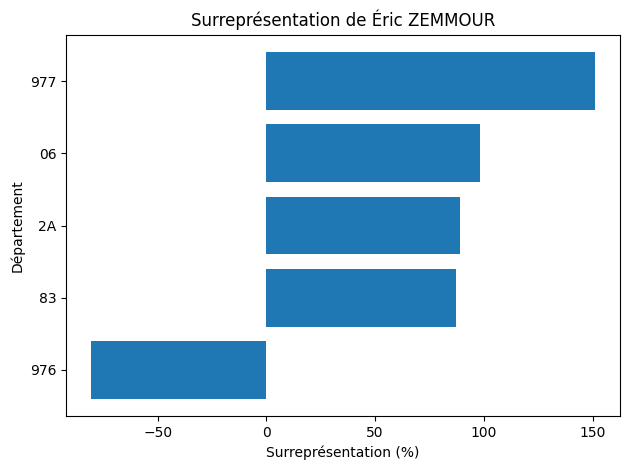

In [11]:
import matplotlib.pyplot as plt

def plot_surrepresentation(score_departements, candidat, top_n):
    # Filtrer candidat
    df_cand = score_departements[
        score_departements["candidat"] == candidat
    ].copy()
    
    # Surreprésentation absolue (intensité)
    df_cand["surrepr_abs"] = df_cand["surrepresentation"].abs()
    
    # Top départements
    df_top = (
        df_cand
        .sort_values("surrepr_abs", ascending=False)
        .head(top_n)
    )
    
    # Tri pour affichage (barres horizontales propres)
    df_top = df_top.sort_values("surrepresentation")
    
    # Plot
    plt.figure()
    plt.barh(df_top["code_departement"], df_top["surrepresentation"])
    
    plt.xlabel("Surreprésentation (%)")
    plt.ylabel("Département")
    plt.title(f"Surreprésentation de {candidat}")
    
    plt.tight_layout()
    plt.show()

plot_surrepresentation(score_departements, "Éric ZEMMOUR", top_n=5)